In [1]:
from math import pi
import numpy as np
import scipy as sp
#from qiskit.opflow import CircuitSampler, StateFn, AerPauliExpectation, PauliSumOp
from qiskit.quantum_info import Pauli
from qiskit.circuit.library import PauliEvolutionGate
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit.circuit import Parameter
from qiskit.circuit.library import TwoLocal
from qiskit_algorithms.optimizers import SciPyOptimizer
from qiskit.primitives import Sampler # new
from qiskit.quantum_info import SparsePauliOp,PauliList
from qiskit.circuit import QuantumCircuit, QuantumRegister
from qiskit.primitives import Estimator # new
import time
import pandas as pd
from qiskit.providers.basic_provider import BasicProvider #new
from multiprocessing import Pool
import multiprocessing as mp
from qiskit_algorithms.optimizers import SciPyOptimizer
import scipy as sp
from scipy.optimize import differential_evolution, Bounds
import os
from scipy.optimize import minimize

In [3]:
def create_ham_str(nqubits):

    # Create a list of terms for the hamiltonian (open boundary conditions)
    # Inputs: nqubits (int), number of qubits
    # Outputs: ham (list), hamiltonian 

    ham = []

    for i in range(nqubits-1):

        term = ''

        for j in range(nqubits-i-2):

            term += 'I'

        for j in range(nqubits-i-2,nqubits-i):

            term += 'Y'  # Choose a Pauli matrix, i.e., X, Y or Z

        for j in range(nqubits-i,nqubits):

            term += 'I'

        ham.append(term)

    return ham



def evaluate_expectation(parameters_values):
    # Function to evaluate the expectation value of the Hamiltonian for a given set of parameters
    # Inputs: parameter_values (ndarray), parameter values
    # Outputs: result (float), energy value

    value_dict = dict(zip(ansatz.parameters, parameters_values))
    pars =  list(value_dict.values())
    expectation_value = estimator.run(ansatz,qubit_op,pars).result().values
    return float(np.real(expectation_value))

In [4]:
import pyade.ilshade 
import numpy as np

# You may want to use a variable so its easier to change it if we want
algorithm = pyade.ilshade 

# We get default parameters for a problem with two variables
params = algorithm.get_default_params(dim=2) 

# We define the boundaries of the variables
params['bounds'] = np.array([[-75, 75]] * 2) 

# We indicate the function we want to minimize
params['func'] = lambda x: x[0]**2 + x[1]**2 + x[0]*x[1] - 500 

# We run the algorithm and obtain the results
solution, fitness = algorithm.apply(**params)



In [ ]:
import pyade.ilshade 
# Set the maximun chain length
min_qubits=3
max_qubits=10

for k in range(min_qubits,max_qubits):
    
    #################################################### Hamiltonian ###########################################################
    
    qubit_op=SparsePauliOp(PauliList(create_ham_str(k)),coeffs=-1.0)
    qubits=k
    depth=1
    #SOMA parameters
    prt = 0.2
    path_lenght = 2
    step = 0.11
    migrations = 20
    pop_size = 15

    #general parameters
    dimension = qubits*4
    min_s = [-3.14]*dimension
    max_s = [3.14]*dimension
    
    ###################################################### Ansatz ##############################################################
    
    q_init=QuantumCircuit(qubit_op.num_qubits)
    for i in range(0,qubit_op.num_qubits):
            q_init.ry(np.pi/4,i)
            
    ansatz=TwoLocal(qubit_op.num_qubits, ['ry','rz'], 'cz', 'linear', reps=1, insert_barriers=True)
    ansatz.compose(q_init,front=True,inplace=True)
    #print(ansatz.decompose().draw(fold=-1))
    
    print('ansatz_num_parameters=',ansatz.num_parameters)
    
    ##################################### Instructions for the energy evaluation ###############################################
    from qiskit_aer.primitives import Estimator

    # Simulations are noiseless and without sampling. 
    #backend = Aer.get_backend('aer_simulator') old
    device = BasicProvider().get_backend('basic_simulator')
    coupling_map = device.configuration().coupling_map
 
    # If a noise model is provided, the Aer primitives
    # perform a "qasm" simulation
    estimator = Estimator(
                backend_options={ # method chosen automatically to match options
                    "coupling_map": coupling_map,
                },
                run_options={"shots": 5120}
            )
 
    
    
    def progress_callback(**kwargs):
        # Access the current generation, fitness, and number of function evaluations from kwargs
        current_generation = kwargs['current_generation']
        fitness = kwargs['fitness']
        num_evals = kwargs['num_evals']
        
        # Print the best fitness in the current generation and the number of function evaluations
        best_fitness = np.min(fitness)
        print(f"Generation {current_generation}: Best Fitness = {best_fitness}, Function Evaluations = {num_evals}")


    
    ######################################## Parameter optimization ###############################################
    algorithm = pyade.ilshade 

    # We get default parameters for a problem with two variables
    params = algorithm.get_default_params(dim=dimension) 
    params["max_evals"] = k * 1000
    params["population_size"] = 50
    # We define the boundaries of the variables
    params['bounds'] = np.array([[-100, 100]] * dimension) 
    params['callback'] = progress_callback

    # We indicate the function we want to minimize
    params['func'] = evaluate_expectation

    # We run the algorithm and obtain the results
    solution, fitness = algorithm.apply(**params)
    print(fitness)
    

ansatz_num_parameters= 12
Generation 0: Best Fitness = -1.404296875, Function Evaluations = 50
Generation 1: Best Fitness = -1.404296875, Function Evaluations = 99
Generation 2: Best Fitness = -1.404296875, Function Evaluations = 147
Generation 3: Best Fitness = -1.404296875, Function Evaluations = 195
Generation 4: Best Fitness = -1.404296875, Function Evaluations = 242
Generation 5: Best Fitness = -1.404296875, Function Evaluations = 288
Generation 6: Best Fitness = -1.412109375, Function Evaluations = 334
Generation 7: Best Fitness = -1.412109375, Function Evaluations = 379
Generation 8: Best Fitness = -1.412109375, Function Evaluations = 423
Generation 9: Best Fitness = -1.412109375, Function Evaluations = 467
Generation 10: Best Fitness = -1.7578125, Function Evaluations = 510
Generation 11: Best Fitness = -1.7578125, Function Evaluations = 552
Generation 12: Best Fitness = -1.7578125, Function Evaluations = 594
Generation 13: Best Fitness = -1.765625, Function Evaluations = 635
G

In [2]:
np.__version__

'1.23.5'

In [ ]:
# Set the maximun chain length
import pyade.mpede
import pyade.lshade

min_qubits=5
max_qubits=6

for k in range(min_qubits,max_qubits):
    
    #################################################### Hamiltonian ###########################################################
    
    qubit_op=SparsePauliOp(PauliList(create_ham_str(k)),coeffs=-1.0)
    qubits=k
    depth=1
    #SOMA parameters
    prt = 0.2
    path_lenght = 2
    step = 0.11
    migrations = 20
    pop_size = 15

    #general parameters
    dimension = qubits*4
    min_s = [-3.14]*dimension
    max_s = [3.14]*dimension
    
    ###################################################### Ansatz ##############################################################
    
    q_init=QuantumCircuit(qubit_op.num_qubits)
    for i in range(0,qubit_op.num_qubits):
            q_init.ry(np.pi/4,i)
            
    ansatz=TwoLocal(qubit_op.num_qubits, ['ry','rz'], 'cz', 'linear', reps=1, insert_barriers=True)
    ansatz.compose(q_init,front=True,inplace=True)
    #print(ansatz.decompose().draw(fold=-1))
    
    print('ansatz_num_parameters=',ansatz.num_parameters)
    
    ##################################### Instructions for the energy evaluation ###############################################
    from qiskit_aer.primitives import Estimator

    # Simulations are noiseless and without sampling. 
    #backend = Aer.get_backend('aer_simulator') old
    device = BasicProvider().get_backend('basic_simulator')
    coupling_map = device.configuration().coupling_map
 
    # If a noise model is provided, the Aer primitives
    # perform a "qasm" simulation
    estimator = Estimator(
                run_options={"shots": 5120}
            )
 
    
    
    def progress_callback(**kwargs):
        # Access the current generation, fitness, and number of function evaluations from kwargs
        current_generation = kwargs['current_generation']
        fitness = kwargs['fitness']
        num_evals = kwargs['num_evals']
        
        # Print the best fitness in the current generation and the number of function evaluations
        best_fitness = np.min(fitness)
        print(f"Generation {current_generation}: Best Fitness = {best_fitness}, Function Evaluations = {num_evals}")


    
    ######################################## Parameter optimization ###############################################
    algorithm = pyade.lshade

    # We get default parameters for a problem with two variables
    params = algorithm.get_default_params(dim=dimension) 
    params["max_evals"] = 50000
    # We define the boundaries of the variables
    params['bounds'] = np.array([[-100, 100]] * dimension) 
    params['callback'] = progress_callback

    # We indicate the function we want to minimize
    params['func'] = evaluate_expectation

    # We run the algorithm and obtain the results
    solution, fitness = algorithm.apply(**params)
    print(fitness)
    

ansatz_num_parameters= 20
Generation 0: Best Fitness = -2.34765625, Function Evaluations = 720
Generation 1: Best Fitness = -2.34765625, Function Evaluations = 1075
Generation 2: Best Fitness = -2.34765625, Function Evaluations = 1427
Generation 3: Best Fitness = -2.34765625, Function Evaluations = 1777
Generation 4: Best Fitness = -2.505859375, Function Evaluations = 2124
Generation 5: Best Fitness = -2.505859375, Function Evaluations = 2469
Generation 6: Best Fitness = -2.505859375, Function Evaluations = 2811
Generation 7: Best Fitness = -2.505859375, Function Evaluations = 3151
Generation 8: Best Fitness = -2.505859375, Function Evaluations = 3489
Generation 9: Best Fitness = -2.505859375, Function Evaluations = 3824
Generation 10: Best Fitness = -2.505859375, Function Evaluations = 4157
Generation 11: Best Fitness = -2.505859375, Function Evaluations = 4487
Generation 12: Best Fitness = -2.505859375, Function Evaluations = 4815
Generation 13: Best Fitness = -2.505859375, Function 

KeyboardInterrupt: 

In [3]:
import numpy as np
from joblib import Parallel, delayed

class Individual:
    """Individual of the population. It holds parameters of the solution as well as the fitness of the solution."""
    def __init__(self, params, fitness):
        self.params = params
        self.fitness = fitness

    def __repr__(self):
        return '{} fitness: {}'.format(self.params, self.fitness)

def evaluate(params):

    return evaluate_expectation(params)

def bounded(params, min_s: list, max_s: list):
    """
    Returns bounded version of params
    All params that are outside of bounds (min_s, max_s) are reassigned by a random number within bounds
    """
    return np.array([np.random.uniform(min_s[d], max_s[d])
            if params[d] < min_s[d] or params[d] > max_s[d] 
            else params[d] 
            for d in range(len(params))])

def generate_population(size, min_s, max_s, dimension):
    def generate_individual():
        params = np.random.uniform(min_s, max_s, dimension)
        fitness = evaluate(params)
        return Individual(params, fitness)
    return [generate_individual() for _ in range(size)]

def generate_prt_vector(prt, dimension):
    return np.random.choice([0, 1], dimension, p=[prt, 1-prt])

def get_leader(population):
    """Finds leader of the population by its fitness (the lower the better)."""
    return min(population, key = lambda individual: individual.fitness)

def update_individual(individual, leader, prt_vector, path_length, step, min_s, max_s):
    next_position = individual.params
    for t in np.arange(step, path_length, step):
        current_position = individual.params + (leader.params - individual.params) * t * prt_vector
        current_position = bounded(current_position, min_s, max_s)
        fitness = evaluate(current_position)
        if fitness <= individual.fitness:
            next_position = current_position
            individual.fitness = fitness
    individual.params = next_position
    return individual

def soma_all_to_one_adaptive(population, prt, path_length, step, migrations, min_s, max_s, dimension):
    for generation in range(migrations):
        leader = get_leader(population)
        prt_vector = generate_prt_vector(prt, dimension)
        updated_population = Parallel(n_jobs=-1)(delayed(update_individual)(
            individual, leader, prt_vector, path_length, step, min_s, max_s) for individual in population)
        population = updated_population
    return get_leader(population)




In [6]:
def soma_all_to_one_rand(population, prt, path_length, step, migrations, min_s, max_s, dimension):
    for generation in range(migrations):
        leading = np.random.choice(population)
        
        # Parallelize the loop over individuals
        updated_population = Parallel(n_jobs=-1)(
            delayed(update_individual)(individual, leading, prt, path_length, step, min_s, max_s, dimension)
            for individual in population
        )
        
        # Update population with updated individuals
        population = updated_population
    
    return get_leader(population)

def update_individual(individual, leading, prt, path_length, step, min_s, max_s, dimension):
    if individual is leading:
        return individual
    
    next_position = individual.params
    prt_vector = generate_prt_vector(prt, dimension)
    for t in np.arange(step, path_length, step):
        current_position = individual.params + (leading.params - individual.params) * t * prt_vector
        current_position = bounded(current_position, min_s, max_s)
        fitness = evaluate(current_position)
        if fitness <= individual.fitness:
            next_position = current_position
            individual.fitness = fitness
    individual.params = next_position
    return individual

In [ ]:
# Set the maximun chain length
min_qubits=3
max_qubits=4

for k in range(min_qubits,max_qubits):
    
    #################################################### Hamiltonian ###########################################################
    
    qubit_op=SparsePauliOp(PauliList(create_ham_str(k)),coeffs=-1.0)
    qubits=k
    depth=1
    #SOMA parameters
    prt = 0.2
    path_lenght = 2
    step = 0.11
    migrations = 20
    pop_size = 15

    #general parameters
    dimension = qubits*4
    min_s = [-3.14]*dimension
    max_s = [3.14]*dimension
    
    ###################################################### Ansatz ##############################################################
    
    q_init=QuantumCircuit(qubit_op.num_qubits)
    for i in range(0,qubit_op.num_qubits):
            q_init.ry(np.pi/4,i)
            
    ansatz=TwoLocal(qubit_op.num_qubits, ['ry','rz'], 'cz', 'linear', reps=1, insert_barriers=True)
    ansatz.compose(q_init,front=True,inplace=True)
    #print(ansatz.decompose().draw(fold=-1))
    
    print('ansatz_num_parameters=',ansatz.num_parameters)
    
    ##################################### Instructions for the energy evaluation ###############################################
    from qiskit_aer.primitives import Estimator

    # Simulations are noiseless and without sampling. 
    #backend = Aer.get_backend('aer_simulator') old
    device = BasicProvider().get_backend('basic_simulator')
    coupling_map = device.configuration().coupling_map
 
    # If a noise model is provided, the Aer primitives
    # perform a "qasm" simulation
    estimator = Estimator(
                run_options={"shots": 5120},
            )
 
    
    
    
    
    ######################################## Parameter optimization ###############################################
    
    # https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html
    
    # Parameter bounds
    bounds=[]
    for j in range(0,ansatz.num_parameters):
        bounds.append((-np.pi,np.pi))
        
    # .csv file to store data
    df = pd.DataFrame(columns=['qubits','time','Energy','F_eval','Iterations'])
    sr= pd.DataFrame(columns=['qubits','SR'])
    # Set the number of workers
    pool=Pool(8)
    
    # Set the total number of optimizations
    optimizations=5
    t0=time.time()
    ground_state_energy=[]
    for d in range(0,optimizations):
        if __name__ == '__main__':
            start=time.time()
            # Random seed. Important when making a job_array
            np.random.seed((os.getpid() * int(time.time())) % 123456789)
            initial_point=2*np.pi*np.random.random(ansatz.num_parameters)-np.pi
            #optimizer = differential_evolution(func=evaluate_expectation,strategy='best1bin',popsize=1,x0=initial_point,bounds=bounds,maxiter=10,disp=True,init='halton',polish=False,tol=1e-3,workers=pool.map, updating='deferred')
            #optimizer = minimize(evaluate_expectation,initial_point,method='COBYLA')
            population = generate_population(pop_size, min_s, max_s, dimension)
            energy = soma_all_to_one_rand(population, prt, path_lenght, step, migrations, min_s, max_s, dimension)
            #optimizer = differential_evolution(func=evaluate_expectation,strategy='best1bin',popsize=1,x0=initial_point,bounds=bounds,maxiter=2000,disp=True,init='halton',polish=False,tol=1e-5, updating='deferred')
            ground_state_energy.append(energy.fitness)
            end=time.time()
            time_per_it=end-start
            new_data = {'qubits': qubits, 'time': time_per_it, 'Energy': energy.fitness, 'F_eval': 15, 'Iterations': migrations}
        new_row = pd.DataFrame([new_data])
        df = pd.concat([df, new_row], ignore_index=True)
    t1=time.time()

    pool.close()
    pool.join()

    print('time_'+str(optimizations)+'_steps=',t1-t0)
   
    count=0
    for i in ground_state_energy:
        if np.abs(i+qubits-1)<=1e-1:
            count=count+1
            
    success_rate=count/len(ground_state_energy)*100
    print('success_rate=', success_rate,'%')
    print('number_of_qubits=',qubits)
    new_data1 = {'qubits':qubits,'SR':success_rate}
    new_row1 = pd.DataFrame([new_data])
    sr = pd.concat([sr, new_row1], ignore_index=True)
    
    print('------------------------------------------')
    print('------------------------------------------')
    print('------------------------------------------')
    print('------------------------------------------')
    df.to_csv('Results.csv')
    sr.to_csv('SR.csv') 

ansatz_num_parameters= 12


C:\Users\petre\AppData\Local\Temp\ipykernel_28344\2715537733.py:93: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, new_row], ignore_index=True)


time_5_steps= 21.76513409614563
success_rate= 100.0 %
number_of_qubits= 3
------------------------------------------
------------------------------------------
------------------------------------------
------------------------------------------


In [ ]:
ansatz.parameters

ParameterView([ParameterVectorElement(θ[0]), ParameterVectorElement(θ[1]), ParameterVectorElement(θ[2]), ParameterVectorElement(θ[3]), ParameterVectorElement(θ[4]), ParameterVectorElement(θ[5]), ParameterVectorElement(θ[6]), ParameterVectorElement(θ[7]), ParameterVectorElement(θ[8]), ParameterVectorElement(θ[9]), ParameterVectorElement(θ[10]), ParameterVectorElement(θ[11])])

In [ ]:
import numpy as np
import time
k=3
qubit_op=SparsePauliOp(PauliList(create_ham_str(k)),coeffs=-1.0)
qubits=k
depth=1

 #general parameters
dimension = qubits*4
min_s = [-3.14]*dimension
max_s = [3.14]*dimension
    
###################################################### Ansatz ##############################################################
    
q_init=QuantumCircuit(qubit_op.num_qubits)
for i in range(0,qubit_op.num_qubits):
        q_init.ry(np.pi/4,i)
            
ansatz=TwoLocal(qubit_op.num_qubits, ['ry','rz'], 'cz', 'linear', reps=1, insert_barriers=True)
ansatz.compose(q_init,front=True,inplace=True)
    
print('ansatz_num_parameters=',ansatz.num_parameters)

##################################### Instructions for the energy evaluation ###############################################
from qiskit_aer.primitives import Estimator

# Simulations are noiseless and without sampling. 
#backend = Aer.get_backend('aer_simulator') old
device = BasicProvider().get_backend('basic_simulator')
coupling_map = device.configuration().coupling_map
 
# If a noise model is provided, the Aer primitives
# perform a "qasm" simulation
estimator = Estimator(
            run_options={"shots": 5120},
        )

def schwefel(params):
    return 418.9829 * len(params) - np.sum(params * np.sin(np.sqrt(np.abs(params))))

class Individual:
    """Individual of the population. It holds parameters of the solution as well as the fitness of the solution."""
    def __init__(self, params, fitness):
        self.params = params
        self.fitness = fitness

    def __repr__(self):
        return '{} fitness: {}'.format(self.params, self.fitness)

def evaluate(params):
    return evaluate_expectation(params)

def generate_population(size, dimension, VarMin, VarMax):
    def cost_function_wrapper(params):
        return evaluate(params)

    pop = VarMin + np.random.rand(size, dimension) * (VarMax - VarMin)
    fitness = np.apply_along_axis(cost_function_wrapper, 1, pop)
    
    population = []
    for i in range(size):
        individual = Individual(pop[i], fitness[i])
        population.append(individual)

    return population

starttime = time.time()                                             # Start the timer
print('Hello! iSOMA is working, please wait... ')
dimension = 4*k                                                      # Number of dimensions of the problem
# -------------- Control Parameters of SOMA -------------------------------
N_jump, Step = 10, 0.3                                              # Assign values ​​to variables: Step, PRT, PathLength
PopSize, Max_Migration, Max_FEs = 100, 100, 10*dimension**4         # Assign values ​​to variables: PopSize, Max_Migration
m, n, s = 10, 5, 15
# -------------- The domain (search space) --------------------------------
VarMin, VarMax = -np.pi, np.pi   # for Schwefel's function.                    # Define the search range

population = generate_population(PopSize, dimension, VarMin, VarMax)
pop = np.array([ind.params for ind in population])
fitness = np.array([ind.fitness for ind in population])
FEs = PopSize                                                       # Count the number of function evaluations
the_best_cost = np.min(fitness)                                     # Find the Global minimum fitness value
# ---------------- SOMA MIGRATIONS ----------------------------------------
best_cost_old = the_best_cost
Migration, Count = 0, 0                                             # Assign values ​​to variables: Migration
while np.abs(the_best_cost+qubits-1)>=1e-1:                                                # Terminate when reaching Max_Migration / User can change to Max_FEs
    Migration = Migration + 1                                       # Increase Migration value
    # ------------ Migrant selection: m -----------------------------------
    M = np.random.choice(range(PopSize),m,replace=False)         # Migrant selection: m
    M_sort = np.argsort(fitness[M])
    for j in range(n):                                              # Choose n individuals move toward the Leader
        Migrant = pop[M[M_sort[j]]].reshape(dimension, 1)        # Get the Migrant position (solution values) in the current population
        # ------------ Leader selection: k --------------------------------
        K = np.random.choice(range(PopSize),s,replace=False)     # Leader selection: k
        K_sort = np.argsort(fitness[K])
        Leader = pop[K[K_sort[1]]].reshape(dimension, 1)         # Get the Migrant position (solution values) in the current population
        if M[M_sort[j]] == K[K_sort[1]]:                            # Don't move if it is itself
            Leader = pop[K[K_sort[2]]].reshape(dimension, 1)     # Get the Migrant position (solution values) in the current population
        # ------ Migrant move to Leader: Jumping --------------------------
        flag, move = 0, 1
        while (flag == 0) and (move <= N_jump):
            nstep = (N_jump-move+1) * Step
            # ------ Update Control parameters: PRT -----------------------
            PRT = 0.1 + 0.9*(FEs / Max_FEs);                        # Update PRT parameter
            # ----- SOMA Mutation -----------------------------------------
            PRTVector = (np.random.rand(dimension,1)<PRT)*1      # If rand() < PRT, PRTVector = 1, else, 0
            #PRTVector = (PRTVector - 1) * (1 - FEs/Max_FEs) + 1     # If rand() < PRT, PRTVector = 1, else, FEs/Max_FEs
            offspring = Migrant + (Leader - Migrant) * nstep * PRTVector # Jumping towards the Leader
            # ------------ Check and put individuals inside the search range if it's outside
            for rw in range(dimension):                             # From row: Check
                if offspring[rw]<VarMin or offspring[rw]>VarMax:    # if outside the search range
                    offspring[rw] = VarMin + np.random.rand() * (VarMax - VarMin) # Randomly put it inside
            # ------------ Evaluate the offspring and Update --------------
            new_cost = evaluate(offspring.flatten())                      # Evaluate the offspring
            FEs = FEs + 1                                           # Count the number of function evaluations
            # ----- SOMA Accepting: Place the Best Offspring to Pop -------
            if new_cost <= fitness[M[M_sort[j]]]:                   # Compare min_new_cost with fitness value of the moving individual
                flag = 1
                fitness[M[M_sort[j]]] = new_cost                    # Replace the moving individual fitness value
                pop[M[M_sort[j]]] = offspring.flatten()                  # Replace the moving individual position (solution values)
                if new_cost <= the_best_cost:                       # Compare Current minimum fitness with Global minimum fitness
                    the_best_cost = new_cost                        # Update Global minimun fitness value
                    the_best_value = offspring                      # Update Global minimun position
                else:
                    Count = Count + 1
            move = move + 1
    if Count > PopSize*50:
        if the_best_cost == best_cost_old:
            rat = round(0.1*PopSize)
            pop_temp = VarMin + np.random.rand(dimension, rat)*(VarMax-VarMin)
            fit_temp = evaluate(pop_temp.flatten())
            FEs = FEs + rat
            D = np.random.choice(range(PopSize),rat,replace=False)
            pop[D] = pop_temp.T
            fitness[D] = fit_temp
        else:
            best_cost_old = the_best_cost
        Count = 0
# %%%%%%%%%%%%%%%%%%    E N D    S O M A     %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
endtime = time.time()                                               # Stop the timer
caltime = endtime - starttime                                       # Caculate the processing time
# %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
# Show the information to User
print('Stop at Migration :  ', Migration)
print('The number of FEs :  ', FEs)
print('Processing time   :  ', caltime, '(s)')
print('The best cost     :  ', the_best_cost)
#print('Solution values   :  ', the_best_value)

timer = []
timer.append(caltime)

#optimizer2=COBYLA(maxiter=100000)
#energy = optimizer2.minimize(fun=evaluate_expectation, x0=the_best_value.reshape((dimension,)))
#print("Best cost after local optimizer:  ", energy.fun)

ansatz_num_parameters= 12
Hello! iSOMA is working, please wait... 
Stop at Migration :   363
The number of FEs :   5292
Processing time   :   18.970962524414062 (s)
The best cost     :   -1.951171875


In [12]:
ansatz.parameters

ParameterView([ParameterVectorElement(θ[0]), ParameterVectorElement(θ[1]), ParameterVectorElement(θ[2]), ParameterVectorElement(θ[3]), ParameterVectorElement(θ[4]), ParameterVectorElement(θ[5]), ParameterVectorElement(θ[6]), ParameterVectorElement(θ[7]), ParameterVectorElement(θ[8]), ParameterVectorElement(θ[9]), ParameterVectorElement(θ[10]), ParameterVectorElement(θ[11])])

In [ ]:
import time
import numpy as np

starttime = time.time()  # Start the timer
timer = []
for k in range(3, 9):  # Iterate over different values of k (number of qubits)
    print(f'Hello! iSOMA is working with k={k}, please wait... ')
    
    qubit_op=SparsePauliOp(PauliList(create_ham_str(k)),coeffs=-1.0)
    qubits=k
    depth=1

    #general parameters
    dimension = qubits*4
    min_s = [-3.14]*dimension
    max_s = [3.14]*dimension
    
    ###################################################### Ansatz ##############################################################
    
    q_init=QuantumCircuit(qubit_op.num_qubits)
    for i in range(0,qubit_op.num_qubits):
            q_init.ry(np.pi/4,i)
            
    ansatz=TwoLocal(qubit_op.num_qubits, ['ry','rz'], 'cz', 'linear', reps=1, insert_barriers=True)
    ansatz.compose(q_init,front=True,inplace=True)
    #print(ansatz.decompose().draw(fold=-1))
    
    print('ansatz_num_parameters=',ansatz.num_parameters)
    
    ##################################### Instructions for the energy evaluation ###############################################
    from qiskit_aer.primitives import Estimator

    # Simulations are noiseless and without sampling. 
    #backend = Aer.get_backend('aer_simulator') old
    device = BasicProvider().get_backend('basic_simulator')
    coupling_map = device.configuration().coupling_map
 
    # If a noise model is provided, the Aer primitives
    # perform a "qasm" simulation
    estimator = Estimator(
                run_options={"shots": 5120},
            )

    dimension = 4 * k  # Number of dimensions of the problem
    
    # Control Parameters of SOMA
    N_jump, Step = 10, 0.3
    PopSize, Max_Migration = 25, 100
    Max_FEs = 100000
    m, n, s = 20, 15, 3
    
    # The domain (search space)
    VarMin, VarMax = -np.pi, np.pi
    
    # Generate initial population
    population = generate_population(PopSize, dimension, VarMin, VarMax)
    pop = np.array([ind.params for ind in population])
    fitness = np.array([ind.fitness for ind in population])
    FEs = PopSize  # Count the number of function evaluations
    the_best_cost = np.min(fitness)  # Find the Global minimum fitness value
    
    # SOMA Migrations
    best_cost_old = the_best_cost
    Migration, Count = 0, 0
    
    while np.abs(the_best_cost + k - 1) >= 1e-1:
        Migration += 1  # Increase Migration value
        
        # Migrant selection
        M = np.random.choice(range(PopSize), m, replace=False)
        M_sort = np.argsort(fitness[M])
        
        for j in range(n):
            Migrant = pop[M[M_sort[j]]].reshape(dimension, 1)
            
            # Leader selection
            K = np.random.choice(range(PopSize), s, replace=False)
            K_sort = np.argsort(fitness[K])
            Leader = pop[K[K_sort[1]]].reshape(dimension, 1)
            
            if M[M_sort[j]] == K[K_sort[1]]:
                Leader = pop[K[K_sort[2]]].reshape(dimension, 1)
            
            flag, move = 0, 1
            
            while (flag == 0) and (move <= N_jump):
                nstep = (N_jump - move + 1) * Step
                
                # Update Control parameters: PRT
                PRT = 0.1 + 0.9 * (FEs / Max_FEs)
                
                # SOMA Mutation
                PRTVector = (np.random.rand(dimension, 1) < PRT) * 1
                offspring = Migrant + (Leader - Migrant) * nstep * PRTVector
                
                # Check and put individuals inside the search range if it's outside
                for rw in range(dimension):
                    if offspring[rw] < VarMin or offspring[rw] > VarMax:
                        offspring[rw] = VarMin + np.random.rand() * (VarMax - VarMin)
                
                new_cost = evaluate(offspring.flatten())
                FEs += 1
                
                if new_cost <= fitness[M[M_sort[j]]]:
                    flag = 1
                    fitness[M[M_sort[j]]] = new_cost
                    pop[M[M_sort[j]]] = offspring.flatten()
                    
                    if new_cost <= the_best_cost:
                        the_best_cost = new_cost
                        the_best_value = offspring
                    else:
                        Count += 1
                
                move += 1
        
        if Count > PopSize * 50:
            if the_best_cost == best_cost_old:
                rat = round(0.1 * PopSize)
                pop_temp = VarMin + np.random.rand(dimension, rat) * (VarMax - VarMin)
                fit_temp = evaluate(pop_temp.flatten())
                FEs += rat
                D = np.random.choice(range(PopSize), rat, replace=False)
                pop[D] = pop_temp.T
                fitness[D] = fit_temp
            else:
                best_cost_old = the_best_cost
            Count = 0
    
    # Stop the timer
    endtime = time.time()
    caltime = endtime - starttime
    
    # Show the information to User
    print('Stop at Migration :  ', Migration)
    print('The number of FEs :  ', FEs)
    print('Processing time   :  ', caltime, '(s)')
    print('The best cost     :  ', the_best_cost)
    # print('Solution values   :  ', the_best_value)
    print("\n")
    timer.append(caltime)



Hello! iSOMA is working with k=3, please wait... 
ansatz_num_parameters= 12


KeyboardInterrupt: 

In [29]:
u = None
3 * 15**4
#0.1 + 0.9 * (80000 / u)

151875

In [35]:
import numpy as np
import time
from scipy.optimize import minimize

def evaluate(parameters_values):
    # Function to evaluate the expectation value of the Hamiltonian for a given set of parameters
    # Inputs: parameter_values (ndarray), parameter values
    # Outputs: result (float), energy value

    value_dict = dict(zip(ansatz.parameters, parameters_values))
    pars =  list(value_dict.values())
    expectation_value = estimator.run(ansatz,qubit_op,pars).result().values
    return np.real(expectation_value)

# Define your initial population generation function
def generate_population(pop_size, dimension, var_min, var_max):
    population = []
    for _ in range(pop_size):
        individual = np.random.uniform(var_min, var_max, dimension)
        fitness = evaluate(individual)
        population.append(Individual(individual, fitness))
    return population

# Define your individual class
class Individual:
    def __init__(self, params, fitness):
        self.params = params
        self.fitness = fitness

# Define the function to evaluate expectation for COBYLA
def evaluate_expectation(x):
    return evaluate(x)

starttime = time.time()  # Start the timer
print('Hello! iSOMA is working, please wait... ')
dimension = 4 * k  # Number of dimensions of the problem
# -------------- Control Parameters of SOMA -------------------------------
N_jump, Step = 10, 0.3  # Assign values ​​to variables: Step, PRT, PathLength
PopSize, Max_Migration, Max_FEs = 100, 100, 10 * dimension**4  # Assign values ​​to variables: PopSize, Max_Migration
m, n, s = 10, 5, 15
local_count, local_better = 0, 0
# -------------- The domain (search space) --------------------------------
VarMin, VarMax = -np.pi, np.pi  # Define the search range

population = generate_population(PopSize, dimension, VarMin, VarMax)
pop = np.array([ind.params for ind in population])
fitness = np.array([ind.fitness for ind in population])
FEs = PopSize  # Count the number of function evaluations
the_best_cost = np.min(fitness)  # Find the Global minimum fitness value
the_best_value = pop[np.argmin(fitness)]  # Find the Global minimum position
# ---------------- SOMA MIGRATIONS ----------------------------------------
best_cost_old = the_best_cost
Migration, Count = 0, 0  # Assign values ​​to variables: Migration
while np.abs(the_best_cost + qubits - 1) >= 1e-1:  # Terminate when reaching Max_Migration / User can change to Max_FEs
    Migration += 1  # Increase Migration value
    # ------------ Migrant selection: m -----------------------------------
    M = np.random.choice(range(PopSize), m, replace=False)  # Migrant selection: m
    M_sort = np.argsort(fitness[M])
    for j in range(n):  # Choose n individuals move toward the Leader
        Migrant = pop[M[M_sort[j]]].reshape(dimension, 1)  # Get the Migrant position (solution values) in the current population
        # ------------ Leader selection: k --------------------------------
        K = np.random.choice(range(PopSize), s, replace=False)  # Leader selection: k
        K_sort = np.argsort(fitness[K])
        Leader = pop[K[K_sort[1]]].reshape(dimension, 1)  # Get the Leader position (solution values) in the current population
        if M[M_sort[j]] == K[K_sort[1]]:  # Don't move if it is itself
            Leader = pop[K[K_sort[2]]].reshape(dimension, 1)  # Get the Leader position (solution values) in the current population
        # ------ Migrant move to Leader: Jumping --------------------------
        flag, move = 0, 1
        while (flag == 0) and (move <= N_jump):
            nstep = (N_jump - move + 1) * Step
            # ------ Update Control parameters: PRT -----------------------
            PRT = 0.1 + 0.9 * (FEs / Max_FEs)  # Update PRT parameter
            # ----- SOMA Mutation -----------------------------------------
            PRTVector = (np.random.rand(dimension, 1) < PRT) * 1  # If rand() < PRT, PRTVector = 1, else, 0
            offspring = Migrant + (Leader - Migrant) * nstep * PRTVector  # Jumping towards the Leader
            # ------------ Check and put individuals inside the search range if it's outside
            for rw in range(dimension):  # From row: Check
                if offspring[rw] < VarMin or offspring[rw] > VarMax:  # if outside the search range
                    offspring[rw] = VarMin + np.random.rand() * (VarMax - VarMin)  # Randomly put it inside
            # ------------ Evaluate the offspring and Update --------------
            new_cost = evaluate(offspring.flatten())  # Evaluate the offspring
            FEs += 1  # Count the number of function evaluations
            # ----- SOMA Accepting: Place the Best Offspring to Pop -------
            if new_cost <= fitness[M[M_sort[j]]]:  # Compare min_new_cost with fitness value of the moving individual
                flag = 1
                fitness[M[M_sort[j]]] = new_cost  # Replace the moving individual fitness value
                pop[M[M_sort[j]]] = offspring.flatten()  # Replace the moving individual position (solution values)
                if new_cost <= the_best_cost:  # Compare Current minimum fitness with Global minimum fitness
                    the_best_cost = new_cost  # Update Global minimum fitness value
                    the_best_value = offspring.flatten()  # Update Global minimum position
                else:
                    Count += 1
            move += 1
    if Count > PopSize * 50:
        if the_best_cost == best_cost_old:
            rat = round(0.1 * PopSize)
            pop_temp = VarMin + np.random.rand(dimension, rat) * (VarMax - VarMin)
            fit_temp = evaluate(pop_temp.flatten())
            FEs += rat
            D = np.random.choice(range(PopSize), rat, replace=False)
            pop[D] = pop_temp.T
            fitness[D] = fit_temp
        else:
            best_cost_old = the_best_cost
        Count = 0
    if Migration % k**2 == 0:
        # Hybrid optimization: Perform local optimization on the best individual
        optimizer2 = minimize(evaluate_expectation, the_best_value.reshape((dimension,)), method='COBYLA', options={'maxiter': 100000})
        local_opt_value = optimizer2.x
        local_opt_cost = optimizer2.fun
        local_count += 1

        # Compare the fitness of the local optimized solution with the best solution
        if local_opt_cost < the_best_cost:
            the_best_cost = local_opt_cost
            the_best_value = local_opt_value
            local_better += 1

# %%%%%%%%%%%%%%%%%%    E N D    S O M A     %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
endtime = time.time()  # Stop the timer
caltime = endtime - starttime  # Calculate the processing time
# %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
# Show the information to User
print('Stop at Migration :  ', Migration)
print('The number of FEs :  ', FEs)
print('Processing time   :  ', caltime, '(s)')
print('The best cost     :  ', the_best_cost)
print('Solution values   :  ', the_best_value)
print('Local opt was better : ', local_better)
print('Local count:   ', local_count)
timer = []
timer.append(caltime)


Hello! iSOMA is working, please wait... 
Stop at Migration :   625
The number of FEs :   13262
Processing time   :   45.893635988235474 (s)
The best cost     :   -3.96875
Solution values   :   [ 2.98988103  2.29677581  0.18619936  2.42985457 -2.67664583  2.78246873
 -0.26694025 -0.42830072  1.80740899  1.79494167  0.91842058  1.46013011
  0.58152754 -1.85910329  0.71913426 -1.26643864 -1.57382101  1.80852101
  1.32108186 -0.5466837 ]
Local opt was better :  2
Local count:    25


In [ ]:
import numpy as np
import time
from scipy.optimize import minimize
k=9
def evaluate(parameters_values):
    # Function to evaluate the expectation value of the Hamiltonian for a given set of parameters
    # Inputs: parameter_values (ndarray), parameter values
    # Outputs: result (float), energy value

    value_dict = dict(zip(ansatz.parameters, parameters_values))
    pars =  list(value_dict.values())
    expectation_value = estimator.run(ansatz,qubit_op,pars).result().values
    return np.real(expectation_value)

# Define your initial population generation function
def generate_population(pop_size, dimension, var_min, var_max):
    population = []
    for _ in range(pop_size):
        individual = np.random.uniform(var_min, var_max, dimension)
        fitness = evaluate(individual)
        population.append(Individual(individual, fitness))
    return population

# Define your individual class
class Individual:
    def __init__(self, params, fitness):
        self.params = params
        self.fitness = fitness

# Define the function to evaluate expectation for COBYLA
def evaluate_expectation(x):
    return evaluate(x)

#################################################### Hamiltonian ###########################################################
    
qubit_op=SparsePauliOp(PauliList(create_ham_str(k)),coeffs=-1.0)
qubits=k
depth=1
#SOMA parameters
prt = 0.2
path_lenght = 2
step = 0.11
migrations = 20
pop_size = 15

#general parameters
dimension = qubits*4
min_s = [-3.14]*dimension
max_s = [3.14]*dimension
    
###################################################### Ansatz ##############################################################

q_init=QuantumCircuit(qubit_op.num_qubits)
for i in range(0,qubit_op.num_qubits):
        q_init.ry(np.pi/4,i)
        
ansatz=TwoLocal(qubit_op.num_qubits, ['ry','rz'], 'cz', 'linear', reps=1, insert_barriers=True)
ansatz.compose(q_init,front=True,inplace=True)
#print(ansatz.decompose().draw(fold=-1))

print('ansatz_num_parameters=',ansatz.num_parameters)

##################################### Instructions for the energy evaluation ###############################################
from qiskit_aer.primitives import Estimator

# Simulations are noiseless and without sampling. 
#backend = Aer.get_backend('aer_simulator') old
device = BasicProvider().get_backend('basic_simulator')
coupling_map = device.configuration().coupling_map

# If a noise model is provided, the Aer primitives
# perform a "qasm" simulation
estimator = Estimator(
            run_options={"shots": 5120},
        )

starttime = time.time()  # Start the timer
print('Hello! iSOMA is working, please wait... ')
dimension = 4 * k  # Number of dimensions of the problem
# -------------- Control Parameters of SOMA -------------------------------
N_jump, Step = 10, 0.3  # Assign values ​​to variables: Step, PRT, PathLength
PopSize, Max_Migration, Max_FEs = 100, 100, 10 * dimension**4  # Assign values ​​to variables: PopSize, Max_Migration
m, n, s = 10, 5, 15
local_better, local_count = 0, 0
# -------------- The domain (search space) --------------------------------
VarMin, VarMax = -np.pi, np.pi  # Define the search range

population = generate_population(PopSize, dimension, VarMin, VarMax)
pop = np.array([ind.params for ind in population])
fitness = np.array([ind.fitness for ind in population])
FEs = PopSize  # Count the number of function evaluations
the_best_cost = np.min(fitness)  # Find the Global minimum fitness value
the_best_value = pop[np.argmin(fitness)]  # Find the Global minimum position
# ---------------- SOMA MIGRATIONS ----------------------------------------
best_cost_old = the_best_cost
Migration, Count = 0, 0  # Assign values ​​to variables: Migration
local_search_interval = 25  # Interval to perform local search
top_n_individuals = 3  # Number of top individuals to perform local search on

while np.abs(the_best_cost + qubits - 1) >= 1e-1:  # Terminate when reaching Max_Migration / User can change to Max_FEs
    Migration += 1  # Increase Migration value
    # ------------ Migrant selection: m -----------------------------------
    M = np.random.choice(range(PopSize), m, replace=False)  # Migrant selection: m
    M_sort = np.argsort(fitness[M])
    for j in range(n):  # Choose n individuals move toward the Leader
        Migrant = pop[M[M_sort[j]]].reshape(dimension, 1)  # Get the Migrant position (solution values) in the current population
        # ------------ Leader selection: k --------------------------------
        K = np.random.choice(range(PopSize), s, replace=False)  # Leader selection: k
        K_sort = np.argsort(fitness[K])
        Leader = pop[K[K_sort[1]]].reshape(dimension, 1)  # Get the Leader position (solution values) in the current population
        if M[M_sort[j]] == K[K_sort[1]]:  # Don't move if it is itself
            Leader = pop[K[K_sort[2]]].reshape(dimension, 1)  # Get the Leader position (solution values) in the current population
        # ------ Migrant move to Leader: Jumping --------------------------
        flag, move = 0, 1
        while (flag == 0) and (move <= N_jump):
            nstep = (N_jump - move + 1) * Step
            # ------ Update Control parameters: PRT -----------------------
            PRT = 0.1 + 0.9 * (FEs / Max_FEs)  # Update PRT parameter
            # ----- SOMA Mutation -----------------------------------------
            PRTVector = (np.random.rand(dimension, 1) < PRT) * 1  # If rand() < PRT, PRTVector = 1, else, 0
            offspring = Migrant + (Leader - Migrant) * nstep * PRTVector  # Jumping towards the Leader
            # ------------ Check and put individuals inside the search range if it's outside
            for rw in range(dimension):  # From row: Check
                if offspring[rw] < VarMin or offspring[rw] > VarMax:  # if outside the search range
                    offspring[rw] = VarMin + np.random.rand() * (VarMax - VarMin)  # Randomly put it inside
            # ------------ Evaluate the offspring and Update --------------
            new_cost = evaluate(offspring.flatten())  # Evaluate the offspring
            FEs += 1  # Count the number of function evaluations
            # ----- SOMA Accepting: Place the Best Offspring to Pop -------
            if new_cost <= fitness[M[M_sort[j]]]:  # Compare min_new_cost with fitness value of the moving individual
                flag = 1
                fitness[M[M_sort[j]]] = new_cost  # Replace the moving individual fitness value
                pop[M[M_sort[j]]] = offspring.flatten()  # Replace the moving individual position (solution values)
                if new_cost <= the_best_cost:  # Compare Current minimum fitness with Global minimum fitness
                    the_best_cost = new_cost  # Update Global minimum fitness value
                    the_best_value = offspring.flatten()  # Update Global minimum position
                else:
                    Count += 1
            move += 1
    if Count > PopSize * 50:
        if the_best_cost == best_cost_old:
            rat = round(0.1 * PopSize)
            pop_temp = VarMin + np.random.rand(dimension, rat) * (VarMax - VarMin)
            fit_temp = evaluate(pop_temp.flatten())
            FEs += rat
            D = np.random.choice(range(PopSize), rat, replace=False)
            pop[D] = pop_temp.T
            fitness[D] = fit_temp
        else:
            best_cost_old = the_best_cost
        Count = 0

    # Hybrid optimization: Perform local optimization every local_search_interval migrations
    if Migration % local_search_interval == 1:
        sorted_indices = np.argsort(fitness)[:top_n_individuals]  # Get the indices of the top N individuals
        for idx in sorted_indices:
            optimizer = SPSA(maxiter=300*k)
            optimizer2 = optimizer.minimize(fun=evaluate_expectation, x0= pop[idx].reshape((dimension,))) 
            local_opt_value = optimizer2.x
            local_opt_cost = optimizer2.fun
            local_count +=1

            # Compare the fitness of the local optimized solution with the original
            if local_opt_cost < fitness[idx]:
                fitness[idx] = local_opt_cost
                pop[idx] = local_opt_value
                # Update the global best if necessary
                if local_opt_cost < the_best_cost:
                    the_best_cost = local_opt_cost
                    the_best_value = local_opt_value
                    local_better +=1

# %%%%%%%%%%%%%%%%%%    E N D    S O M A     %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
endtime = time.time()  # Stop the timer
caltime = endtime - starttime  # Calculate the processing time
# %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
# Show the information to User
print('Stop at Migration :  ', Migration)
print('The number of FEs :  ', FEs)
print('Processing time   :  ', caltime, '(s)')
print('The best cost     :  ', the_best_cost)
print('Solution values   :  ', the_best_value)
print('Local count:   ', local_count)
print('Local was better:   ', local_better)
timer = []
timer.append(caltime)


ansatz_num_parameters= 36
Hello! iSOMA is working, please wait... 
Stop at Migration :   1
The number of FEs :   119
Processing time   :   72.86763453483582 (s)
The best cost     :   [-8.]
Solution values   :   [  4.13838696   8.64311064   1.02725383  -0.77802287  -8.97363457
   5.50272098   5.78417602   2.34907746 -11.84199368  -8.36246599
 -14.19697602  -1.6349886    3.88497537   1.34116615  -4.93151646
   0.90018911   3.53434757   3.11887863   5.85564749  -1.56087978
  -1.37122265  -4.71725578   4.1532207   -1.56403579  -4.5149153
 -17.26834216  -3.08199866  -2.62578166   1.57206823   0.2426595
  -4.70991924   2.73284563   4.71573679  -4.49144298  11.00234309
  -7.87953412]
Local count:    3
Local was better:    2


In [ ]:
import numpy as np
import time
from scipy.optimize import minimize

def evaluate(parameters_values):
    # Function to evaluate the expectation value of the Hamiltonian for a given set of parameters
    # Inputs: parameter_values (ndarray), parameter values
    # Outputs: result (float), energy value

    value_dict = dict(zip(ansatz.parameters, parameters_values))
    pars = list(value_dict.values())
    expectation_value = estimator.run(ansatz, qubit_op, pars).result().values
    return np.real(expectation_value)

# Define your initial population generation function
def generate_population(pop_size, dimension, var_min, var_max):
    population = []
    for _ in range(pop_size):
        individual = np.random.uniform(var_min, var_max, dimension)
        fitness = evaluate(individual)
        population.append(Individual(individual, fitness))
    return population

# Define your individual class
class Individual:
    def __init__(self, params, fitness):
        self.params = params
        self.fitness = fitness

# Define the function to evaluate expectation for COBYLA
def evaluate_expectation(x):
    return evaluate(x)

# Loop over different values of k (number of qubits)
for k in range(3, 11):
    dimension = k*4
    total_time = 0
    print(f"Running optimization for k = {k} (number of qubits)")

    #################################################### Hamiltonian ###########################################################
    
    qubit_op=SparsePauliOp(PauliList(create_ham_str(k)),coeffs=-1.0)
    qubits=k
    depth=1
    #SOMA parameters
    prt = 0.2
    path_lenght = 2
    step = 0.11
    migrations = 20
    pop_size = 15

    #general parameters
    dimension = qubits*4
    min_s = [-3.14]*dimension
    max_s = [3.14]*dimension
    
    ###################################################### Ansatz ##############################################################
    
    q_init=QuantumCircuit(qubit_op.num_qubits)
    for i in range(0,qubit_op.num_qubits):
            q_init.ry(np.pi/4,i)
            
    ansatz=TwoLocal(qubit_op.num_qubits, ['ry','rz'], 'cz', 'linear', reps=1, insert_barriers=True)
    ansatz.compose(q_init,front=True,inplace=True)
    #print(ansatz.decompose().draw(fold=-1))
    
    print('ansatz_num_parameters=',ansatz.num_parameters)
    
    ##################################### Instructions for the energy evaluation ###############################################
    from qiskit_aer.primitives import Estimator

    # Simulations are noiseless and without sampling. 
    #backend = Aer.get_backend('aer_simulator') old
    device = BasicProvider().get_backend('basic_simulator')
    coupling_map = device.configuration().coupling_map
 
    # If a noise model is provided, the Aer primitives
    # perform a "qasm" simulation
    estimator = Estimator(
                run_options={"shots": 5120},
            )

    for run in range(3):
        starttime = time.time()  # Start the timer
        print(f"Run {run + 1} for k = {k}")
        dimension = 4 * k  # Number of dimensions of the problem
        # -------------- Control Parameters of SOMA -------------------------------
        N_jump, Step = 10, 0.3  # Assign values ​​to variables: Step, PRT, PathLength
        PopSize, Max_Migration, Max_FEs = 100, 100, 10 * dimension**4  # Assign values ​​to variables: PopSize, Max_Migration
        m, n, s = 10, 5, 15
        local_better, local_count = 0, 0
        # -------------- The domain (search space) --------------------------------
        VarMin, VarMax = -np.pi, np.pi  # Define the search range

        population = generate_population(PopSize, dimension, VarMin, VarMax)
        pop = np.array([ind.params for ind in population])
        fitness = np.array([ind.fitness for ind in population])
        FEs = PopSize  # Count the number of function evaluations
        the_best_cost = np.min(fitness)  # Find the Global minimum fitness value
        the_best_value = pop[np.argmin(fitness)]  # Find the Global minimum position
        # ---------------- SOMA MIGRATIONS ----------------------------------------
        best_cost_old = the_best_cost
        Migration, Count = 0, 0  # Assign values ​​to variables: Migration
        local_search_interval = 25  # Adaptive local search interval
        top_n_individuals = 3  # Number of top individuals to perform local search on

        while np.abs(the_best_cost + qubits - 1) >= 1e-1:  # Terminate when reaching Max_Migration / User can change to Max_FEs
            Migration += 1  # Increase Migration value
            # ------------ Migrant selection: m -----------------------------------
            M = np.random.choice(range(PopSize), m, replace=False)  # Migrant selection: m
            M_sort = np.argsort(fitness[M])
            for j in range(n):  # Choose n individuals move toward the Leader
                Migrant = pop[M[M_sort[j]]].reshape(dimension, 1)  # Get the Migrant position (solution values) in the current population
                # ------------ Leader selection: k --------------------------------
                K = np.random.choice(range(PopSize), s, replace=False)  # Leader selection: k
                K_sort = np.argsort(fitness[K])
                Leader = pop[K[K_sort[1]]].reshape(dimension, 1)  # Get the Leader position (solution values) in the current population
                if M[M_sort[j]] == K[K_sort[1]]:  # Don't move if it is itself
                    Leader = pop[K[K_sort[2]]].reshape(dimension, 1)  # Get the Leader position (solution values) in the current population
                # ------ Migrant move to Leader: Jumping --------------------------
                flag, move = 0, 1
                while (flag == 0) and (move <= N_jump):
                    nstep = (N_jump - move + 1) * Step
                    # ------ Update Control parameters: PRT -----------------------
                    PRT = 0.1 + 0.9 * (FEs / Max_FEs)  # Update PRT parameter
                    # ----- SOMA Mutation -----------------------------------------
                    PRTVector = (np.random.rand(dimension, 1) < PRT) * 1  # If rand() < PRT, PRTVector = 1, else, 0
                    offspring = Migrant + (Leader - Migrant) * nstep * PRTVector  # Jumping towards the Leader
                    # ------------ Check and put individuals inside the search range if it's outside
                    for rw in range(dimension):  # From row: Check
                        if offspring[rw] < VarMin or offspring[rw] > VarMax:  # if outside the search range
                            offspring[rw] = VarMin + np.random.rand() * (VarMax - VarMin)  # Randomly put it inside
                    # ------------ Evaluate the offspring and Update --------------
                    new_cost = evaluate(offspring.flatten())  # Evaluate the offspring
                    FEs += 1  # Count the number of function evaluations
                    # ----- SOMA Accepting: Place the Best Offspring to Pop -------
                    if new_cost <= fitness[M[M_sort[j]]]:  # Compare min_new_cost with fitness value of the moving individual
                        flag = 1
                        fitness[M[M_sort[j]]] = new_cost  # Replace the moving individual fitness value
                        pop[M[M_sort[j]]] = offspring.flatten()  # Replace the moving individual position (solution values)
                        if new_cost <= the_best_cost:  # Compare Current minimum fitness with Global minimum fitness
                            the_best_cost = new_cost  # Update Global minimum fitness value
                            the_best_value = offspring.flatten()  # Update Global minimum position
                        else:
                            Count += 1
                    move += 1
            if Count > PopSize * 50:
                if the_best_cost == best_cost_old:
                    rat = round(0.1 * PopSize)
                    pop_temp = VarMin + np.random.rand(dimension, rat) * (VarMax - VarMin)
                    fit_temp = evaluate(pop_temp.flatten())
                    FEs += rat
                    D = np.random.choice(range(PopSize), rat, replace=False)
                    pop[D] = pop_temp.T
                    fitness[D] = fit_temp
                else:
                    best_cost_old = the_best_cost
                Count = 0

            # Adaptive hybrid optimization: Perform local optimization
            if Migration % local_search_interval == 5:
                sorted_indices = np.argsort(fitness)[:top_n_individuals]  # Get the indices of the top N individuals
                for idx in sorted_indices:
                    #optimizer2 = minimize(evaluate_expectation, pop[idx].reshape((dimension,)), method='COBYLA', options={'maxiter': 100000})
                    optimizer = SPSA(maxiter=300*k)
                    optimizer2 = optimizer.minimize(fun=evaluate_expectation, x0= pop[idx].reshape((dimension,))) 
                    local_opt_value = optimizer2.x
                    local_opt_cost = optimizer2.fun
                    local_count += 1

                    # Compare the fitness of the local optimized solution with the original
                    if local_opt_cost < fitness[idx]:
                        fitness[idx] = local_opt_cost
                        pop[idx] = local_opt_value
                        # Update the global best if necessary
                        if local_opt_cost < the_best_cost:
                            the_best_cost = local_opt_cost
                            the_best_value = local_opt_value
                            local_better += 1

        # %%%%%%%%%%%%%%%%%%    E N D    S O M A     %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
        endtime = time.time()  # Stop the timer
        caltime = endtime - starttime  # Calculate the processing time
        total_time += caltime
        # %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
        # Show the information to User
        print('Stop at Migration :  ', Migration)
        print('The number of FEs :  ', FEs)
        print('Processing time   :  ', caltime, '(s)')
        print('The best cost     :  ', the_best_cost)
        #print('Solution values   :  ', the_best_value)
        print('Local count       :  ', local_count)
        print('Local was better  :  ', local_better)

    average_time = total_time / 3
    print(f"Average processing time for k = {k} (number of qubits): {average_time:.2f} seconds\n")


Running optimization for k = 3 (number of qubits)
ansatz_num_parameters= 12
Run 1 for k = 3
Stop at Migration :   5
The number of FEs :   132
Processing time   :   17.96475911140442 (s)
The best cost     :   [-2.]
Local count       :   3
Local was better  :   1
Run 2 for k = 3


KeyboardInterrupt: 

In [3]:
!pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ---------------------------------------- 0.0/165.5 kB ? eta -:--:--
     -- ------------------------------------- 10.2/165.5 kB ? eta -:--:--
     --------------------- ----------------- 92.2/165.5 kB 1.7 MB/s eta 0:00:01
     -------------------------------------  163.8/165.5 kB 2.5 MB/s eta 0:00:01
     -------------------------------------- 165.5/165.5 kB 1.1 MB/s eta 0:00:00
  Using cached pyparsing-3.1.2-py3-none-any.whl.metadata (5.1 kB)
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
    --------------------------------------- 0.2/8.0 MB 5.9 MB/s eta 0:00:02
   -- ------------------------------------- 0.5/8.0 MB 6.4 MB/s eta 0:00:02
   ---- ----------------------------------- 0.9/8.0 MB 6.9 MB/s eta 0:00:02
   ------ --------------------------------- 1.3/8.0 MB 7.5 MB/s eta 0:00:01
   -------- ------------------------------- 1.8/8.0 MB 8.0 MB/s eta 0:00:01
   ----------- -------------------

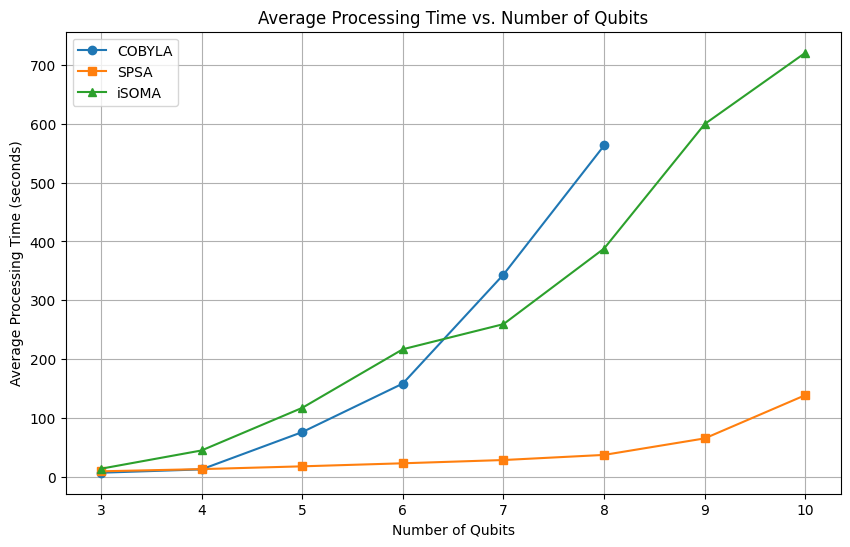

In [8]:
import matplotlib.pyplot as plt

# Data
qubits = [3, 4, 5, 6, 7, 8, 9, 10]
times_cobyla = [7.13, 12.80, 76.09, 158.60, 343.76, 563.01]
times_spsa = [9.53, 13.25, 17.98, 23.15, 28.69, 37.40, 65.47, 139.00]
times_isoma = [13.90, 44.95, 117.29, 216.89, 259.54, 388.03, 599.58, 720.61]

# Truncate to match lengths
qubits_cobyla = qubits[:6]
qubits_spsa = qubits

# Plot
plt.figure(figsize=(10, 6))
plt.plot(qubits_cobyla, times_cobyla, label='COBYLA', marker='o')
plt.plot(qubits_spsa, times_spsa, label='SPSA', marker='s')
plt.plot(qubits, times_isoma, label='iSOMA', marker='^')
plt.xlabel('Number of Qubits')
plt.ylabel('Average Processing Time (seconds)')
plt.title('Average Processing Time vs. Number of Qubits')
plt.legend()
plt.grid(True)
plt.show()


In [3]:
!pip install cma

   ---------------------------------------- 0.0/260.7 kB ? eta -:--:--
   ---------------------------------------- 0.0/260.7 kB ? eta -:--:--
   --- ------------------------------------ 20.5/260.7 kB ? eta -:--:--
   ------- ------------------------------- 51.2/260.7 kB 871.5 kB/s eta 0:00:01
   ---------------------------------------  256.0/260.7 kB 2.6 MB/s eta 0:00:01
   ---------------------------------------  256.0/260.7 kB 2.6 MB/s eta 0:00:01
   ---------------------------------------  256.0/260.7 kB 2.6 MB/s eta 0:00:01
   ---------------------------------------  256.0/260.7 kB 2.6 MB/s eta 0:00:01
   ---------------------------------------  256.0/260.7 kB 2.6 MB/s eta 0:00:01
   ---------------------------------------  256.0/260.7 kB 2.6 MB/s eta 0:00:01
   ---------------------------------------  256.0/260.7 kB 2.6 MB/s eta 0:00:01
   ---------------------------------------  256.0/260.7 kB 2.6 MB/s eta 0:00:01
   ---------------------------------------  256.0/260.7 kB 2.6 MB/

In [ ]:
# Set the maximun chain length
min_qubits=3
max_qubits=10

for k in range(min_qubits,max_qubits):
    
    #################################################### Hamiltonian ###########################################################
    
    qubit_op=SparsePauliOp(PauliList(create_ham_str(k)),coeffs=-1.0)
    qubits=k
    depth=1
    #SOMA parameters
    prt = 0.2
    path_lenght = 2
    step = 0.11
    migrations = 20
    pop_size = 15

    #general parameters
    dimension = qubits*4
    min_s = [-3.14]*dimension
    max_s = [3.14]*dimension
    
    ###################################################### Ansatz ##############################################################
    
    q_init=QuantumCircuit(qubit_op.num_qubits)
    for i in range(0,qubit_op.num_qubits):
            q_init.ry(np.pi/4,i)
            
    ansatz=TwoLocal(qubit_op.num_qubits, ['ry','rz'], 'cz', 'linear', reps=1, insert_barriers=True)
    ansatz.compose(q_init,front=True,inplace=True)
    #print(ansatz.decompose().draw(fold=-1))
    
    print('ansatz_num_parameters=',ansatz.num_parameters)
    
    ##################################### Instructions for the energy evaluation ###############################################
    from qiskit_aer.primitives import Estimator

    # Simulations are noiseless and without sampling. 
    #backend = Aer.get_backend('aer_simulator') old
    device = BasicProvider().get_backend('basic_simulator')
    coupling_map = device.configuration().coupling_map
 
    # If a noise model is provided, the Aer primitives
    # perform a "qasm" simulation
    estimator = Estimator(
                run_options={"shots": 5120},
            )
 
    
    
    
    
    ######################################## Parameter optimization ###############################################
    
    # https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html
    
    # Parameter bounds
    bounds=[]
    for j in range(0,ansatz.num_parameters):
        bounds.append((-np.pi,np.pi))
        
    # .csv file to store data
    df = pd.DataFrame(columns=['qubits','time','Energy','F_eval','Iterations'])
    sr= pd.DataFrame(columns=['qubits','SR'])
    # Set the number of workers
    pool=Pool(8)
    import cma
    import numpy as np

    # Define the objective function to be optimized

    # Initial guess
    x0 = np.random.rand(k*4)  # 10-dimensional problem

    # Standard deviation of the initial population
    sigma0 = 0.5  

    # Options for CMA-ES
    options = {
        'maxiter': 100000,             # Maximum number of iterations
        'popsize': 50,               # Population size
        'tolx': 1e-1,                # Tolerance in x
        'tolfun': 1e-1,              # Tolerance in function value
        'verb_disp': 1,              # Display verbosity
    }

    # Optimize using CMA-ES

    # Set the total number of optimizations
    optimizations=1
    t0=time.time()
    ground_state_energy=[]
    for d in range(0,optimizations):
        if __name__ == '__main__':
            start=time.time()
            # Random seed. Important when making a job_array
            np.random.seed((os.getpid() * int(time.time())) % 123456789)
            result = cma.fmin(evaluate_expectation, x0, sigma0, options)
            end=time.time()
            time_per_it=end-start
            new_data = {'qubits': qubits, 'time': time_per_it, 'Energy': result[1], 'F_eval': result[2], 'Iterations': result[3]}
            ground_state_energy.append(result[1])
        new_row = pd.DataFrame([new_data])
        df = pd.concat([df, new_row], ignore_index=True)
    t1=time.time()

    pool.close()
    pool.join()

    #print('time_'+str(optimizations)+'_steps=',t1-t0)
   
    count=0
    for i in ground_state_energy:
        if np.abs(i+qubits-1)<=1e-1:
            count=count+1
            
    success_rate=count/len(ground_state_energy)*100
    print('success_rate=', success_rate,'%')
    print('number_of_qubits=',qubits)
    new_data1 = {'qubits':qubits,'SR':success_rate}
    new_row1 = pd.DataFrame([new_data])
    sr = pd.concat([sr, new_row1], ignore_index=True)
    # Print the optimization result
    print("Best solution found: ", result[0])
    print("Objective value: ", result[1])
    print("Number of function evaluations: ", result[2])
    print("Number of iterations: ", result[3])
    print('------------------------------------------')
    print('------------------------------------------')
    print('------------------------------------------')
    print('------------------------------------------')
    df.to_csv('Results.csv')
    sr.to_csv('SR.csv')

ansatz_num_parameters= 12
(25_w,50)-aCMA-ES (mu_w=14.0,w_1=14%) in dimension 12 (seed=646928, Tue Oct 22 13:49:39 2024)
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1     50 -1.031250000000000e+00 1.0e+00 4.86e-01  5e-01  5e-01 0:00.1
    2    100 -1.468750000000000e+00 1.2e+00 5.75e-01  5e-01  6e-01 0:00.4
    3    150 -1.531250000000000e+00 1.5e+00 5.86e-01  6e-01  6e-01 0:00.5
    4    200 -1.812500000000000e+00 1.6e+00 6.26e-01  6e-01  7e-01 0:00.6
    5    250 -1.812500000000000e+00 1.7e+00 6.27e-01  6e-01  7e-01 0:00.8
    6    300 -1.906250000000000e+00 1.7e+00 6.37e-01  5e-01  7e-01 0:00.9
    7    350 -1.750000000000000e+00 1.9e+00 5.66e-01  5e-01  6e-01 0:01.0
    8    400 -1.968750000000000e+00 2.0e+00 5.44e-01  4e-01  6e-01 0:01.2
    9    450 -1.906250000000000e+00 2.0e+00 4.93e-01  4e-01  5e-01 0:01.3
   10    500 -2.000000000000000e+00 2.0e+00 4.62e-01  3e-01  5e-01 0:01.5
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m

C:\Users\petre\AppData\Local\Temp\ipykernel_28732\3616225095.py:109: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, new_row], ignore_index=True)


(25_w,50)-aCMA-ES (mu_w=14.0,w_1=14%) in dimension 16 (seed=717619, Tue Oct 22 13:49:43 2024)
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1     50 -8.437500000000000e-01 1.0e+00 4.99e-01  5e-01  5e-01 0:00.6
    2    100 -1.812500000000000e+00 1.2e+00 5.21e-01  5e-01  5e-01 0:00.8
    3    150 -1.312500000000000e+00 1.3e+00 5.65e-01  5e-01  6e-01 0:00.9
    4    200 -1.375000000000000e+00 1.5e+00 6.70e-01  6e-01  7e-01 0:01.1
    5    250 -1.406250000000000e+00 1.6e+00 6.94e-01  6e-01  8e-01 0:01.2
    6    300 -1.750000000000000e+00 1.7e+00 7.56e-01  7e-01  8e-01 0:01.4
    7    350 -1.656250000000000e+00 1.7e+00 7.31e-01  6e-01  8e-01 0:01.5
    8    400 -1.937500000000000e+00 1.8e+00 7.33e-01  6e-01  8e-01 0:01.7
    9    450 -1.843750000000000e+00 1.7e+00 7.83e-01  7e-01  9e-01 0:01.8
   10    500 -1.781250000000000e+00 1.8e+00 7.13e-01  6e-01  8e-01 0:01.9
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
   11    550 -1.968750

C:\Users\petre\AppData\Local\Temp\ipykernel_28732\3616225095.py:109: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, new_row], ignore_index=True)


Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1     50 -1.031250000000000e+00 1.0e+00 5.35e-01  5e-01  6e-01 0:00.4
    2    100 -1.562500000000000e+00 1.2e+00 6.16e-01  6e-01  7e-01 0:00.7
    3    150 -1.937500000000000e+00 1.3e+00 7.29e-01  7e-01  8e-01 0:00.8
    4    200 -2.125000000000000e+00 1.3e+00 7.67e-01  7e-01  8e-01 0:01.0
    5    250 -1.625000000000000e+00 1.3e+00 7.74e-01  7e-01  8e-01 0:01.2
    6    300 -1.750000000000000e+00 1.4e+00 8.27e-01  8e-01  9e-01 0:01.3
    7    350 -2.125000000000000e+00 1.5e+00 8.36e-01  8e-01  9e-01 0:01.5
    8    400 -1.843750000000000e+00 1.5e+00 8.49e-01  8e-01  9e-01 0:01.7
    9    450 -1.718750000000000e+00 1.5e+00 8.47e-01  8e-01  9e-01 0:01.8
   10    500 -2.125000000000000e+00 1.6e+00 8.63e-01  8e-01  9e-01 0:02.0
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
   11    550 -2.406250000000000e+00 1.6e+00 9.22e-01  8e-01  1e+00 0:02.2
   12    600 -2.750000000000000e+00 1.6e+0

C:\Users\petre\AppData\Local\Temp\ipykernel_28732\3616225095.py:109: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, new_row], ignore_index=True)


Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1     50 -1.187500000000000e+00 1.0e+00 4.84e-01  5e-01  5e-01 0:00.4
    2    100 -1.687500000000000e+00 1.1e+00 5.02e-01  5e-01  5e-01 0:00.5
    3    150 -2.468750000000000e+00 1.2e+00 5.80e-01  6e-01  6e-01 0:00.7
    4    200 -2.218750000000000e+00 1.3e+00 6.31e-01  6e-01  6e-01 0:00.9
    5    250 -2.406250000000000e+00 1.3e+00 7.11e-01  7e-01  7e-01 0:01.1
    6    300 -1.875000000000000e+00 1.4e+00 7.90e-01  8e-01  8e-01 0:01.3
    7    350 -1.843750000000000e+00 1.5e+00 8.20e-01  8e-01  8e-01 0:01.4
    8    400 -2.500000000000000e+00 1.5e+00 8.11e-01  8e-01  8e-01 0:01.6
    9    450 -2.593750000000000e+00 1.5e+00 8.02e-01  8e-01  8e-01 0:01.8
   10    500 -2.250000000000000e+00 1.6e+00 7.53e-01  7e-01  8e-01 0:02.0
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
   11    550 -3.343750000000000e+00 1.6e+00 7.15e-01  6e-01  7e-01 0:02.2
   12    600 -2.875000000000000e+00 1.6e+0

C:\Users\petre\AppData\Local\Temp\ipykernel_28732\3616225095.py:109: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, new_row], ignore_index=True)


Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1     50 -2.156250000000000e+00 1.0e+00 4.93e-01  5e-01  5e-01 0:00.5
    2    100 -2.187500000000000e+00 1.1e+00 5.09e-01  5e-01  5e-01 0:00.8
    3    150 -2.031250000000000e+00 1.2e+00 5.29e-01  5e-01  5e-01 0:01.0


KeyboardInterrupt: 

In [ ]:
#######################################SOMA T3A#############################################


import time
import numpy as np

starttime = time.time()  # Start the timer
timer = []
for k in range(3, 9):  # Iterate over different values of k (number of qubits)
    print(f'Hello! SOMA T3A is working with k={k}, please wait... ')
    
    qubit_op=SparsePauliOp(PauliList(create_ham_str(k)),coeffs=-1.0)
    qubits=k
    depth=1

    #general parameters
    dimension = qubits*4
    min_s = [-3.14]*dimension
    max_s = [3.14]*dimension
    
    ###################################################### Ansatz ##############################################################
    
    q_init=QuantumCircuit(qubit_op.num_qubits)
    for i in range(0,qubit_op.num_qubits):
            q_init.ry(np.pi/4,i)
            
    ansatz=TwoLocal(qubit_op.num_qubits, ['ry','rz'], 'cz', 'linear', reps=1, insert_barriers=True)
    ansatz.compose(q_init,front=True,inplace=True)
    #print(ansatz.decompose().draw(fold=-1))
    
    print('ansatz_num_parameters=',ansatz.num_parameters)
    
    ##################################### Instructions for the energy evaluation ###############################################
    from qiskit_aer.primitives import Estimator

    # Simulations are noiseless and without sampling. 
    #backend = Aer.get_backend('aer_simulator') old
    device = BasicProvider().get_backend('basic_simulator')
    coupling_map = device.configuration().coupling_map
 
    # If a noise model is provided, the Aer primitives
    # perform a "qasm" simulation
    estimator = Estimator(
                run_options={"shots": 5120},
            )

    dimension = 4 * k  # Number of dimensions of the problem
    
    import numpy as np
    import time

    # Custom evaluation function
    def evaluate_expectation(parameters_values):
        # Function to evaluate the expectation value of the Hamiltonian for a given set of parameters
        # Inputs: parameter_values (ndarray), parameter values
        # Outputs: result (float), energy value

        value_dict = dict(zip(ansatz.parameters, parameters_values))
        pars = list(value_dict.values())
        expectation_value = estimator.run(ansatz, qubit_op, pars).result().values
        return np.real(expectation_value)

    # Start the timer
    starttime = time.time()

    # Number of dimensions of the problem
    dimension = k*4

    # -------------- Control Parameters of SOMA -------------------------------
    N_jump = 50
    PopSize, Max_Migration, Max_FEs = 100, 100, dimension * 10**4
    m, n, k = 10, 5, 10

    # -------------- The domain (search space) --------------------------------
    VarMin, VarMax = -np.pi, np.pi  # Define the search range

    # %%%%%%%%%%%%%%      B E G I N    S O M A    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%
    # ------------- Create the initial Population -----------------------------
    pop = VarMin + np.random.rand(dimension, PopSize) * (VarMax - VarMin)
    fitness = np.array([evaluate_expectation(ind) for ind in pop.T])
    FEs = PopSize
    the_best_cost = min(fitness)
    the_best_value = pop[:, np.argmin(fitness)]

    # ---------------- SOMA MIGRATIONS ----------------------------------------
    Migration = 0
    while FEs < Max_FEs and np.abs(the_best_cost+qubits-1)>=1e-1:
        Migration += 1
        PRT = 0.05 + 0.90 * (FEs / Max_FEs)
        Step = 0.15 - 0.08 * (FEs / Max_FEs)
        
        # ------------ Migrant selection: m -----------------------------------
        M = np.random.choice(range(PopSize), m, replace=False)
        M_sort = np.argsort(fitness[M])
        
        for j in range(n):
            Migrant = pop[:, M[M_sort[j]]].reshape(dimension, 1)
            
            # ------------ Leader selection: k --------------------------------
            K = np.random.choice(range(PopSize), k, replace=False)
            K_sort = np.argsort(fitness[K])
            Leader = pop[:, K[K_sort[1]]].reshape(dimension, 1)
            
            if M[M_sort[j]] != K[K_sort[1]]:
                offspring_path = np.empty([dimension, 0])
                
                for move in range(N_jump):
                    nstep = (move + 1) * Step
                    PRTVector = (np.random.rand(dimension, 1) < PRT) * 1
                    offspring = Migrant + (Leader - Migrant) * nstep * PRTVector
                    offspring_path = np.append(offspring_path, offspring, axis=1)
                
                size = np.shape(offspring_path)
                
                # ------------ Check and put individuals inside the search range if it's outside
                for cl in range(size[1]):
                    for rw in range(dimension):
                        if offspring_path[rw][cl] < VarMin or offspring_path[rw][cl] > VarMax:
                            offspring_path[rw][cl] = VarMin + np.random.rand() * (VarMax - VarMin)
                
                # ------------ Evaluate the offspring and Update -------------
                new_cost = np.array([evaluate_expectation(ind) for ind in offspring_path.T])
                FEs += size[1]
                min_new_cost = min(new_cost)
                
                # ----- Accepting: Place the best offspring into the current population
                if min_new_cost <= fitness[M[M_sort[j]]]:
                    idz = np.argmin(new_cost)
                    fitness[M[M_sort[j]]] = min_new_cost
                    pop[:, M[M_sort[j]]] = offspring_path[:, idz].reshape(dimension, 1) 

                    # ----- Update the global best value --------------------
                    if min_new_cost <= the_best_cost:
                        the_best_cost = min_new_cost
                        the_best_value = offspring_path[:, idz].reshape(dimension, ) 

    # %%%%%%%%%%%%%%%%%%    E N D    S O M A     %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
    endtime = time.time()  # Stop the timer
    caltime = endtime - starttime  # Calculate the processing time

    # %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
    # Show the information to User
    print('Stop at Migration :  ', Migration)
    print('The number of FEs :  ', FEs)
    print('Processing time   :  ', caltime, '(s)')
    print('The best cost     :  ', the_best_cost)
    #print('Solution values   :  ', the_best_value)



Hello! SOMA T3A is working with k=3, please wait... 
ansatz_num_parameters= 12
Stop at Migration :   12
The number of FEs :   3100
Processing time   :   10.395002841949463 (s)
The best cost     :   [-1.90625]
Hello! SOMA T3A is working with k=4, please wait... 
ansatz_num_parameters= 16
Stop at Migration :   75
The number of FEs :   18850
Processing time   :   54.34876036643982 (s)
The best cost     :   [-2.96875]
Hello! SOMA T3A is working with k=5, please wait... 
ansatz_num_parameters= 20
Stop at Migration :   162
The number of FEs :   40250
Processing time   :   124.54352521896362 (s)
The best cost     :   [-3.90625]
Hello! SOMA T3A is working with k=6, please wait... 
ansatz_num_parameters= 24
Stop at Migration :   961
The number of FEs :   237900
Processing time   :   811.75337266922 (s)
The best cost     :   [-4.90625]
Hello! SOMA T3A is working with k=7, please wait... 
ansatz_num_parameters= 28


KeyboardInterrupt: 

In [17]:
import numpy as np
import time

# Custom Schwefel function for testing
def Schwefel(pop):
    return 418.9829 * pop.shape[0] - np.sum(pop * np.sin(np.sqrt(np.abs(pop))), axis=0)

# Start the timer
starttime = time.time()
print('Hello! SOMA T3A is working, please wait... ')

# Number of dimensions of the problem
dimension = 10

# -------------- Control Parameters of SOMA -------------------------------
N_jump = 45
PopSize, Max_Migration, Max_FEs = 100, 100, dimension * 10**4
m, n, k = 10, 5, 10

# -------------- The domain (search space) --------------------------------
VarMin, VarMax = -500, 500  # for Schwefel's function

# %%%%%%%%%%%%%%      B E G I N    S O M A    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%
# ------------- Create the initial Population -----------------------------
pop = VarMin + np.random.rand(dimension, PopSize) * (VarMax - VarMin)
fitness = Schwefel(pop)
FEs = PopSize
the_best_cost = min(fitness)
the_best_value = pop[:, np.argmin(fitness)]

# ---------------- SOMA MIGRATIONS ----------------------------------------
Migration = 0
while FEs < Max_FEs:
    Migration += 1
    PRT = 0.05 + 0.90 * (FEs / Max_FEs)
    Step = 0.15 - 0.08 * (FEs / Max_FEs)
    
    # ------------ Migrant selection: m -----------------------------------
    M = np.random.choice(range(PopSize), m, replace=False)
    M_sort = np.argsort(fitness[M])
    
    for j in range(n):
        Migrant = pop[:, M[M_sort[j]]].reshape(dimension, 1)
        
        # ------------ Leader selection: k --------------------------------
        K = np.random.choice(range(PopSize), k, replace=False)
        K_sort = np.argsort(fitness[K])
        Leader = pop[:, K[K_sort[1]]].reshape(dimension, 1)
        
        if M[M_sort[j]] != K[K_sort[1]]:
            offspring_path = np.empty([dimension, 0])
            
            for move in range(N_jump):
                nstep = (move + 1) * Step
                PRTVector = (np.random.rand(dimension, 1) < PRT) * 1
                offspring = Migrant + (Leader - Migrant) * nstep * PRTVector
                offspring_path = np.append(offspring_path, offspring, axis=1)
            
            size = np.shape(offspring_path)
            
            # ------------ Check and put individuals inside the search range if it's outside
            for cl in range(size[1]):
                for rw in range(dimension):
                    if offspring_path[rw][cl] < VarMin or offspring_path[rw][cl] > VarMax:
                        offspring_path[rw][cl] = VarMin + np.random.rand() * (VarMax - VarMin)
            
            # ------------ Evaluate the offspring and Update -------------
            new_cost = Schwefel(offspring_path)
            FEs += size[1]
            min_new_cost = min(new_cost)
            
            # ----- Accepting: Place the best offspring into the current population
            if min_new_cost <= fitness[M[M_sort[j]]]:
                idz = np.argmin(new_cost)
                fitness[M[M_sort[j]]] = min_new_cost
                pop[:, M[M_sort[j]]] = offspring_path[:, idz]
                
                # ----- Update the global best value --------------------
                if min_new_cost <= the_best_cost:
                    the_best_cost = min_new_cost
                    the_best_value = offspring_path[:, idz]

# %%%%%%%%%%%%%%%%%%    E N D    S O M A     %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
endtime = time.time()  # Stop the timer
caltime = endtime - starttime  # Calculate the processing time

# %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
# Show the information to User
print('Stop at Migration :  ', Migration)
print('The number of FEs :  ', FEs)
print('Processing time   :  ', caltime, '(s)')
print('The best cost     :  ', the_best_cost)
print('Solution values   :  ', the_best_value)


Hello! SOMA T3A is working, please wait... 
Stop at Migration :   453
The number of FEs :   100000
Processing time   :   3.185326337814331 (s)
The best cost     :   0.00012728497222269652
Solution values   :   [420.96873464 420.96868477 420.96878572 420.96874497 420.96875094
 420.96874082 420.96883845 420.96863358 420.96889647 420.96890292]
